# Probabilidad Clásica

## Conceptos Fundamentales

En probabilidad clásica (modelo laplaciano):

- **Experimento aleatorio**: Proceso que produce resultados inciertos.
- **Espacio muestral** $\Omega$: Conjunto de todos los posibles resultados. Hipótesis: $\# \Omega < +\infty$.
- **Eventos**: Subconjuntos de $\Omega$.
- **Función de probabilidad**: $P: \mathcal{P}(\Omega) \to [0,1]$ tal que:
  $$P(\{\omega\}) = \frac{1}{\# \Omega}$$
  
En particular, si $A \subseteq \Omega$ (evento), entonces:
$$P(A) = \frac{\# A}{\# \Omega}$$

## 1. Experimento: Lanzamiento de dos dados

**Problema**: Lanzar un par de dados honestos. Nos interesa la **suma** de los dados en cada tirada.

### 1.1 Espacio muestral

$$\Omega = \{(i,j) : 1 \leq i,j \leq 6\} = \{1,2,3,4,5,6\} \times \{1,2,3,4,5,6\}$$

$$\# \Omega = 6^2 = 36$$

In [1]:
from itertools import product

Omega = set(product([1, 2, 3, 4, 5, 6], repeat=2))
print(f"Cardinalidad de Omega: {len(Omega)}")

Cardinalidad de Omega: 36


### 1.2 Eventos

Sea $S_n$ el evento: "La suma de los dados es $n$".

$$S_n = \{(i,j) \in \Omega : i + j = n\}$$

In [2]:
def S(n):
    return {(i, j) for i in range(1, 7) for j in range(1, 7) if i + j == n}

print(f"S(9) = {S(9)}")
print(f"|S(9)| = {len(S(9))}")
print(f"P(S(9)) = {len(S(9))}/{len(Omega)} = {len(S(9))/len(Omega):.3f}")

S(9) = {(6, 3), (4, 5), (5, 4), (3, 6)}
|S(9)| = 4
P(S(9)) = 4/36 = 0.111


**Observación**:
$$\sum_{i=2}^{12} P(S(i)) = 1$$

In [3]:
suma_probabilidades = sum(len(S(i))/len(Omega) for i in range(2, 13))
print(f"Suma de probabilidades: {suma_probabilidades:.0f}")

Suma de probabilidades: 1


### Otro tipo de eventos

Sea $T_n$ el evento: "La resta de los dados es mayor o igual que $n$".

$$T_n = \{(i,j) \in \Omega : i - j \geq n\}$$

In [4]:
def T(n):
    return [(i, j) for i in range(1, 7) for j in range(1, 7) if i - j >= n]

print(f"T(2) = {T(2)}")
print(f"|T(2)| = {len(T(2))}")
print(f"P(T(2)) = {len(T(2))}/{len(Omega)} = {len(T(2))/len(Omega):.3f}")

T(2) = [(3, 1), (4, 1), (4, 2), (5, 1), (5, 2), (5, 3), (6, 1), (6, 2), (6, 3), (6, 4)]
|T(2)| = 10
P(T(2)) = 10/36 = 0.278


## 2. Variable Aleatoria Asociada a $S_n$

### 2.1 Función de Probabilidad

In [5]:
from fractions import Fraction

def P(A):
    return Fraction(len(A), len(Omega))

In [6]:
# Crear diccionario de sumas
S_dict = {(i, j): i + j for i, j in Omega}

from collections import defaultdict
dS = defaultdict(set)
for key, value in S_dict.items():
    dS[value].add(key)

# Calcular probabilidades
leyS = {i: P(A) for i, A in dS.items()}

print("Ley de S:")
for k, v in sorted(leyS.items()):
    print(f"  P(S={k}) = {v} = {float(v):.4f}")

Ley de S:
  P(S=2) = 1/36 = 0.0278
  P(S=3) = 1/18 = 0.0556
  P(S=4) = 1/12 = 0.0833
  P(S=5) = 1/9 = 0.1111
  P(S=6) = 5/36 = 0.1389
  P(S=7) = 1/6 = 0.1667
  P(S=8) = 5/36 = 0.1389
  P(S=9) = 1/9 = 0.1111
  P(S=10) = 1/12 = 0.0833
  P(S=11) = 1/18 = 0.0556
  P(S=12) = 1/36 = 0.0278


### 2.2 Ley de una Variable Aleatoria

La **variable aleatoria** es:
$$S: \Omega \to \{2,3,4,5,6,7,8,9,10,11,12\}$$

La **ley de $S$** está determinada por el conjunto $\{(k, p_k)\}$ donde:
$$p_k = P(\{\omega \in \Omega : S(\omega) = k\})$$

In [7]:
import pandas as pd
import numpy as np

# Crear DataFrame
rango_S = list(range(2, 13))
p_k = [float(leyS.get(k, 0)) for k in rango_S]

lS = pd.DataFrame({
    'Suma': rango_S,
    'Probabilidad': [f"{leyS[k]}" for k in rango_S],
    'Decimal': p_k
})

print("Tabla de distribución de S:")
display(lS)

Tabla de distribución de S:


,Suma,Probabilidad,Decimal
0,2,1/36,0.027778
1,3,1/18,0.055556
2,4,1/12,0.083333
3,5,1/9,0.111111
4,6,5/36,0.138889
5,7,1/6,0.166667
6,8,5/36,0.138889
7,9,1/9,0.111111
8,10,1/12,0.083333
9,11,1/18,0.055556


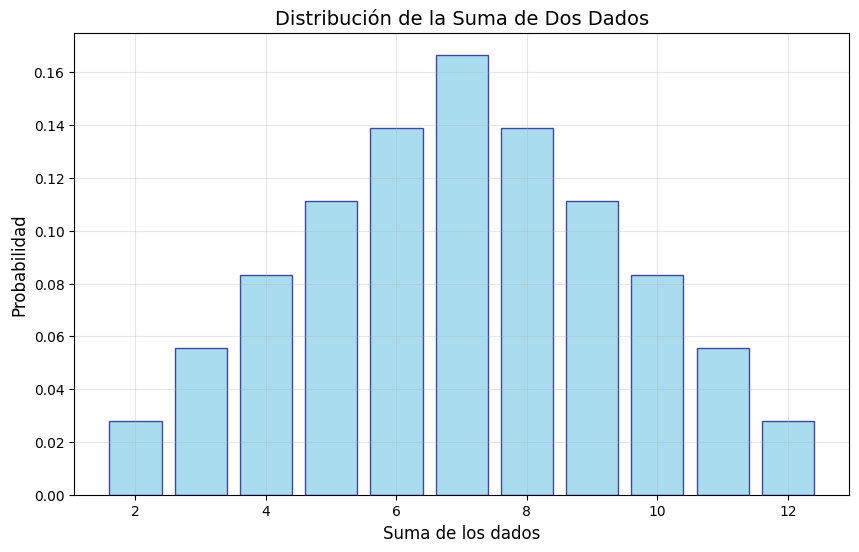

In [8]:
# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(rango_S, p_k, color='skyblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Suma de los dados', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Distribución de la Suma de Dos Dados', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Lanzamiento de una Moneda

**Experimento**: Se lanzan 3 monedas justas de manera independiente.

- $A = \{\text{cae águila}\}$
- $S = \{\text{cae sol}\}$

$$\Omega = \{A, S\} \times \{A, S\} \times \{A, S\}$$
$$\# \Omega = 2^3 = 8$$

In [9]:
Omega_moneda = set(product(["A", "S"], repeat=3))
print(f"Espacio muestral: {Omega_moneda}")
print(f"Cardinalidad: {len(Omega_moneda)}")

Espacio muestral: {('A', 'A', 'S'), ('S', 'A', 'A'), ('A', 'S', 'S'), ('S', 'S', 'A'), ('A', 'A', 'A'), ('S', 'A', 'S'), ('A', 'S', 'A'), ('S', 'S', 'S')}
Cardinalidad: 8


### Eventos

Sea $E$: "Las tres monedas son águila".

Si $A_i$ es el evento: "El resultado del $i$-ésimo lanzamiento es águila", entonces:
$$E = A_1 \cap A_2 \cap A_3$$

In [10]:
# Definir eventos
A_1 = {om for om in Omega_moneda if om[0] == "A"}
A_2 = {om for om in Omega_moneda if om[1] == "A"}
A_3 = {om for om in Omega_moneda if om[2] == "A"}

E = A_1 & A_2 & A_3

print(f"E = {E}")
print(f"P(E) = {len(E)}/{len(Omega_moneda)} = {len(E)/len(Omega_moneda):.3f}")

E = {('A', 'A', 'A')}
P(E) = 1/8 = 0.125


In [11]:
# Usando .count()
E2 = {om for om in Omega_moneda if om.count("A") == 3}
print(f"E (usando count) = {E2}")

E (usando count) = {('A', 'A', 'A')}


### 3.1 Probabilidad Condicional e Independencia

**Definición**: Si $P(F) > 0$, la probabilidad condicional de $E$ dado $F$ es:
$$P(E \mid F) = \frac{P(E \cap F)}{P(F)}$$

In [12]:
def P_cond(E, F):
    return Fraction(len(E & F), len(F))

# Ejemplo: P(E | A_1)
print(f"P(E | A_1) = {P_cond(E, A_1)} = {float(P_cond(E, A_1)):.3f}")

P(E | A_1) = 1/4 = 0.250


**Pregunta**: ¿Cuál es la probabilidad de obtener "sol" en el segundo lanzamiento dado que se obtuvo "águila" en el primero?

In [13]:
B_2 = {om for om in Omega_moneda if om[1] == "S"}

print(f"P(B_2 | A_1) = {P_cond(B_2, A_1)} = {float(P_cond(B_2, A_1)):.3f}")
print(f"P(B_2) = {len(B_2)}/{len(Omega_moneda)} = {len(B_2)/len(Omega_moneda):.3f}")

print(f"\n¿Son independientes? {P_cond(B_2, A_1) == len(B_2)/len(Omega_moneda)}")

P(B_2 | A_1) = 1/2 = 0.500
P(B_2) = 4/8 = 0.500

¿Son independientes? True


### 3.2 Lanzamiento de Monedas Injustas (Volados)

**Modelo frecuentista**:
$$f_n(A) = \frac{n(A)}{n}$$

$$f(A) = \lim_{n \to \infty} f_n(A)$$

In [14]:
import random

def volado(p):
    return 'sol' if random.random() < p else 'águila'

# Simular 10 lanzamientos con p=0.4
resultados = [volado(0.4) for _ in range(10)]
print(f"10 lanzamientos: {resultados}")
print(f"Número de soles: {resultados.count('sol')}")

10 lanzamientos: ['sol', 'águila', 'sol', 'sol', 'águila', 'águila', 'águila', 'águila', 'sol', 'sol']
Número de soles: 5


In [15]:
# Simulación con 1000 repeticiones
p = []
for _ in range(1000):
    N = 10
    resultados = [volado(0.63) for _ in range(N)]
    p.append(resultados.count("sol") / N)

prob_promedio = sum(p) / 1000
print(f"Probabilidad promedio: {prob_promedio:.3f}")

Probabilidad promedio: 0.631


## 4. Urnas

**Problema**: Una urna contiene 23 bolas: 8 blancas (W), 6 azules (B), y 9 rojas (R).

Se seleccionan 6 bolas al azar. Calcular:
1. Todas sean rojas.
2. 3 azules, 2 blancas, 1 roja.
3. Exactamente 4 blancas.

In [16]:
from itertools import combinations

# Crear urna
def conc(A, B):
    return {a + b for a in A for b in B}

urna = conc('W', '12345678') | conc('B', '123456') | conc('R', '123456789')
print(f"Urna: {len(urna)} bolas")

def comb(items, n):
    return {' '.join(combo) for combo in combinations(items, n)}

Omega_urna = comb(urna, 6)
print(f"Espacio muestral: {len(Omega_urna)} combinaciones")

Urna: 23 bolas
Espacio muestral: 100947 combinaciones


In [17]:
# 1. Todas rojas
R6 = {s for s in Omega_urna if s.count('R') == 6}
prob_R6 = Fraction(len(R6), len(Omega_urna))
print(f"P(todas rojas) = {prob_R6} = {float(prob_R6):.6f}")

# 2. 3 azules, 2 blancas, 1 roja
B3W2R1 = {s for s in Omega_urna if s.count('B') == 3 and s.count('W') == 2 and s.count('R') == 1}
prob_B3W2R1 = Fraction(len(B3W2R1), len(Omega_urna))
print(f"P(3 azules, 2 blancas, 1 roja) = {prob_B3W2R1} = {float(prob_B3W2R1):.6f}")

# 3. Exactamente 4 blancas
W4 = {s for s in Omega_urna if s.count('W') == 4}
prob_W4 = Fraction(len(W4), len(Omega_urna))
print(f"P(exactamente 4 blancas) = {prob_W4} = {float(prob_W4):.6f}")

P(todas rojas) = 4/4807 = 0.000832
P(3 azules, 2 blancas, 1 roja) = 240/4807 = 0.049927
P(exactamente 4 blancas) = 350/4807 = 0.072810


## 5. Problema Adicional: Dos Urnas

**Problema**: Se tienen 2 urnas, cada una con 10 bolas numeradas del 1 al 10. Se selecciona una bola de cada urna. Calcular la probabilidad de que los números difieran por 2 o más.

### Solución Analítica

$$\Omega = \{1,\dots,10\} \times \{1,\dots,10\}$$
$$\# \Omega = 100$$

Evento $A$: $|i-j| \geq 2$

$$\# A = 72$$
$$P(A) = \frac{72}{100} = \frac{18}{25}$$

In [18]:
Omega_urnas = set(product(range(1, 11), repeat=2))

A = {(i, j) for i, j in Omega_urnas if abs(i - j) >= 2}

prob_A = Fraction(len(A), len(Omega_urnas))
print(f"P(|i-j| >= 2) = {prob_A} = {float(prob_A):.3f}")
print(f"Cardinalidad de A: {len(A)}")

P(|i-j| >= 2) = 18/25 = 0.720
Cardinalidad de A: 72


### Verificación usando el complemento

$$A^c = \{(i,j): |i-j| \leq 1\}$$
$$\# A^c = 10 + 9 + 9 = 28$$
$$P(A) = 1 - \frac{28}{100} = \frac{72}{100}$$

In [19]:
Ac = {(i, j) for i, j in Omega_urnas if abs(i - j) <= 1}

print(f"|A^c| = {len(Ac)}")
print(f"P(A) = 1 - {len(Ac)}/{len(Omega_urnas)} = {1 - len(Ac)/len(Omega_urnas):.3f}")

|A^c| = 28
P(A) = 1 - 28/100 = 0.720


## 6. Resumen de Resultados

| Experimento | Espacio Muestral | Cardinalidad | Evento | Probabilidad |
|-------------|------------------|--------------|---------|--------------|
| Lanzamiento de 2 dados | $\{1,\dots,6\}^2$ | 36 | Suma = 9 | $\frac{4}{36} = \frac{1}{9}$ |
| Lanzamiento de 3 monedas | $\{A,S\}^3$ | 8 | 3 águilas | $\frac{1}{8}$ |
| Urna (23 bolas) | $\binom{23}{6}$ | 100,947 | 4 blancas | $\frac{350}{4807} \approx 0.073$ |
| Dos urnas (1-10) | $\{1,\dots,10\}^2$ | 100 | $|i-j| \geq 2$ | $\frac{18}{25} = 0.72$ |

## 7. Conceptos Clave

### Ley de Laplace
$$P(A) = \frac{\#A}{\#\Omega}$$

### Probabilidad Condicional
$$P(E \mid F) = \frac{P(E \cap F)}{P(F)}$$

### Independencia
$$P(E \cap F) = P(E) \cdot P(F)$$

### Complemento
$$P(A^c) = 1 - P(A)$$

In [20]:
print("="*60)
print("RESUMEN FINAL - PROBABILIDAD CLÁSICA")
print("="*60)
print("\n1. P(A) = |A| / |Ω| (Ley de Laplace)")
print("2. P(E|F) = P(E∩F) / P(F) (Probabilidad condicional)")
print("3. P(E∩F) = P(E)·P(F) (Independencia)")
print("4. P(A^c) = 1 - P(A) (Complemento)")
print("\n" + "="*60)

RESUMEN FINAL - PROBABILIDAD CLÁSICA

1. P(A) = |A| / |Ω| (Ley de Laplace)
2. P(E|F) = P(E∩F) / P(F) (Probabilidad condicional)
3. P(E∩F) = P(E)·P(F) (Independencia)
4. P(A^c) = 1 - P(A) (Complemento)

